# Plot ROI number per field
- code from previous notebook [link](plot_roi_number_qi_threshold.ipynb)
- applied to all fields

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import datajoint as dj
import datetime
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

from djimaging.utils import plot_utils, math_utils, trace_utils

/workspace/.venv/lib/python3.12/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Create access to djimaging database

In [3]:
username = !whoami
username = username[0]
username

'fsalomon'

In [4]:
home_directory = os.path.expanduser("~")
home_directory

'/gpfs01/euler/User/fsalomon'

In [5]:
# Path to djimaging
path_to_djimaging = f'{home_directory}/github/eulerlab/'

# Clone djimaging if you haven't downloaded it yet
# assert os.isdir(path_to_djimaging), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging} && git clone git@github.com:eulerlab/djimaging.git

# Install djimaging if not done yet
# assert os.isdir(os.path.join(path_to_djimaging, 'djimaging')), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging}/djimaging/ && sudo pip install -e .

## Prepare dj config

In [6]:
# Set config file
config_file = f'{home_directory}/GitHub/docker/dj_{username}_conf.json'
assert os.path.isfile(config_file), f'Set the path to your config file: {config_file}'

In [7]:
# Define a schema name or use the default name for your personal test schema
# It should start with ageuler and have some meaningful name after that
schema_name = f"ageuler_{username}_neuromodulation_ac"

In [8]:
# Do you want to use the RGC classifier?
# If so, make sure to add the respective tables into your schema.
use_rgc_classifier = False

if use_rgc_classifier:  # Define any existing outputfolder for the classifier to be saved
    output_folder = f'{home_directory}/datajoint/rgc_classifier'
    assert os.path.isdir(output_folder), f'Set path to output directory: {output_folder}'

In [9]:
# Load configuration for user
dj.config.load(config_file)
dj.config['schema_name'] = schema_name

if use_rgc_classifier:
    from djimaging.tables.classifier.rgc_classifier import prepare_dj_config_rgc_classifier
    prepare_dj_config_rgc_classifier(output_folder)

print("schema_name:", dj.config['schema_name'])
dj.conn()

[2025-11-05 14:15:05,498][INFO]: DataJoint is configured from /gpfs01/euler/User/fsalomon/GitHub/docker/dj_fsalomon_conf.json
[2025-11-05 14:15:05,567][INFO]: DataJoint 0.14.6 connected to fsalomon@172.25.240.200:3306


schema_name: ageuler_fsalomon_neuromodulation_ac


DataJoint connection (connected) fsalomon@172.25.240.200:3306

## Load schema

In [10]:
# Import your own schema, which defines the tables you will have in your database and how they are connected.
from djimaging.user.amacrine_cells_neuromodulation.schemas.amacrine_cells_neuromodulation_schema import *

In [11]:
if use_rgc_classifier:
    try:
        CelltypeAssignment()
    except Exception as e:
        import warnings
        warnings.warn("""
            If you want to include the RGC classifier in your database, you have to copy the respective tables from 
            djimaging/schemas/full_rgc_schema.py 
            to the schema you just imported (see above).
            Then restart the notebook and try again.
            """)

## Important note

If the schema with the name `schema_name = f"ageuler_{username}_test"` already exists, it is important that the schema definition here is the same as it was when the schema was created.
If you did the other tutorial first, and did not delete (=drop) the schema afterwards, this will not be the case, for example.
Then you already have a schema with the same name but different tables, the first being based on the schema `rgc_classifier_schema`, and this one being based on `my_schema`. This can result in a variety of problems, so you either have to change the schema name here or drop the old schema first.

Outside of this tutorial, in most cases, you want exactly one schema per project to never run into this problem.

## Activate Schema

In [12]:
from djimaging.utils.dj_utils import activate_schema

activate_schema(schema=schema, create_schema=True, create_tables=True)
schema

Schema `ageuler_fsalomon_neuromodulation_ac`

# Example for field XY3

- fields were recorded pairwise
    - e.g., XY1/XY2 are from the same piece of the retina (in this case dorsal)
    - XY3/XY4 are from the same piece of the retina (in this case nasal)
- example how to compute the numbers for pairwise ROIs for the field XY3 computed here

In [13]:
# Retrieve # of ROIs in field XY3 from that date
rois_XY3 = (ChirpQI() & {"date": datetime.date(2025, 10, 23), "field": "XY3", "cond2": "C1", "stim_name": "gChirp"}).fetch("roi_id")
print(f"Number of ROIs in XY3 unfiltered: {len(rois_XY3)}")
print(f"Which ROIs: {rois_XY3}")

Number of ROIs in XY3 unfiltered: 113
Which ROIs: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113]


In [14]:
# Retrieve # of ROIs in field XY3 (QI > 0.3 in C1) from that date
rois_XY3_C1_filtered = ((ChirpQI() & {"date": datetime.date(2025, 10, 23), "field": "XY3", "cond2": "C1", "stim_name": "gChirp"}) & "qidx > 0.3").fetch("roi_id")
print(f"Number of ROIs in XY3 with C1 QI > 0.3: {len(rois_XY3_C1_filtered)}")
print(f"Which ROIs: {rois_XY3_C1_filtered}")

Number of ROIs in XY3 with C1 QI > 0.3: 51
Which ROIs: [  2   3  12  15  23  25  26  29  33  35  36  38  42  46  48  49  55  60
  64  65  74  75  76  78  80  81  83  85  86  89  90  91  92  93  94  95
  96  97  98  99 100 101 102 104 105 106 107 109 110 111 113]


In [15]:
# Retrieve # of ROIs in field XY3 (QI > 0.3 in C2) from that date
rois_XY3_C2_filtered = ((ChirpQI() & {"date": datetime.date(2025, 10, 23), "field": "XY3", "cond2": "C2", "stim_name": "gChirp"}) & "qidx > 0.3").fetch("roi_id")
print(f"Number of ROIs in XY3 with C2 QI > 0.3: {len(rois_XY3_C2_filtered)}")
print(f"Which ROIs: {rois_XY3_C2_filtered}")

Number of ROIs in XY3 with C2 QI > 0.3: 95
Which ROIs: [  1   2   3   4   5   6   7   8  10  11  12  13  14  15  16  17  18  19
  20  21  22  23  24  27  28  29  30  31  33  34  35  36  37  38  39  40
  42  43  44  45  46  47  48  49  50  51  52  53  54  56  57  58  59  60
  61  63  65  66  67  69  70  71  72  75  76  77  78  79  83  84  86  87
  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106
 107 109 110 111 113]


In [16]:
# Retrieve ROIs which are common in both QI filtered conditions
common_rois = [int(x) for x in set(rois_XY3_C1_filtered) & set(rois_XY3_C2_filtered)]
print(f"Number of ROIs in C1 and C2 (QI > 0.3): {len(common_rois)}")
print(f"Which ROIs: {common_rois}")

Number of ROIs in C1 and C2 (QI > 0.3): 43
Which ROIs: [2, 3, 12, 15, 23, 29, 33, 35, 36, 38, 42, 46, 48, 49, 60, 65, 75, 76, 78, 83, 86, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 104, 105, 106, 107, 109, 110, 111, 113]


- Plot different fractions in a bar plot for that field

In [17]:
# Collect raw numbers in an array
# Nedded for plotting the raw numbers above the bars
numbers_of_fractions = [
    len(rois_XY3),
    len(rois_XY3_C1_filtered),
    len(rois_XY3_C2_filtered),
    len(common_rois)]
numbers_of_fractions

[113, 51, 95, 43]

In [18]:
# Calculate fractions (percentages) used for plotting
fractions = [
    len(rois_XY3)/len(rois_XY3) * 100,
    len(rois_XY3_C1_filtered)/len(rois_XY3) * 100,
    len(rois_XY3_C2_filtered)/len(rois_XY3) * 100,
    len(common_rois)/len(rois_XY3) * 100]
fractions

[100.0, 45.13274336283185, 84.070796460177, 38.05309734513274]

In [19]:
# Make labels for plot
labels = ["C1 unfiltered", 
          "C1 QI > 0.3", 
          "C2 QI > 0.3",
          "C1 QI > 0.3 & C2 QI > 0.3"]
labels

['C1 unfiltered', 'C1 QI > 0.3', 'C2 QI > 0.3', 'C1 QI > 0.3 & C2 QI > 0.3']

(0.0, 110.0)

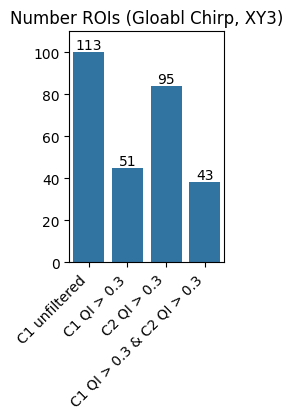

In [20]:
# Make the barplot
fig, axs = plt.subplots(1, 1, figsize=(2,3))
axs = sns.barplot(
    y=fractions,
    x=labels,
)

# Annotate absolute number to the bars
for bar, number in zip(axs.patches, numbers_of_fractions):
    height = bar.get_height()
    axs.text(
        bar.get_x() + bar.get_width() / 2, # x position: center of the bar
        height,                            # y position: top of the bar
        str(number),                       # label to show
        ha='center',                       # horizontal alignment
        va='bottom')                       # vertical alignment, slightly above the bar
    
# Adjust the plot
plt.title("Number ROIs (Gloabl Chirp, XY3)")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 110)

# For all fields, 23.10.2025
## Global Chirp

In [59]:
# Define date, and stimulus
date = datetime.date(2025, 10, 23)
stimulus = "gChirp"

In [60]:
# Retrieve all fields of that day
fields = (ChirpQI() & {"date": date, "stim_name": stimulus}).fetch("field")
fields = np.unique(fields)
fields

array(['XY1', 'XY2', 'XY3', 'XY4', 'XY5', 'XY6', 'XY7', 'XY8'],
      dtype=object)

In [61]:
# Retrieve all conditions on that date
conditions = (ChirpQI() & {"date": date, "stim_name": stimulus}).fetch("cond2")
conditions = np.unique(conditions)
conditions

array(['C1', 'C2', 'DETANO'], dtype=object)

In [62]:
# Retrieve # of ROIs in all fields with global chirp QI > 0.3
for field in fields:
    rois_filtered = ((ChirpQI() & {"date": date, "field": field, "cond2": "C1", "stim_name": stimulus}) & "qidx > 0.3").fetch("roi_id")
    print(f"Number of ROIs in {field} with C1 QI > 0.3: {len(rois_filtered)}")

Number of ROIs in XY1 with C1 QI > 0.3: 3
Number of ROIs in XY2 with C1 QI > 0.3: 105
Number of ROIs in XY3 with C1 QI > 0.3: 51
Number of ROIs in XY4 with C1 QI > 0.3: 189
Number of ROIs in XY5 with C1 QI > 0.3: 179
Number of ROIs in XY6 with C1 QI > 0.3: 165
Number of ROIs in XY7 with C1 QI > 0.3: 171
Number of ROIs in XY8 with C1 QI > 0.3: 30


In [63]:
# Adapt code to all conditions
for field in fields:
    for condition in conditions:
        rois_filtered = ((ChirpQI() & {"date": date, "field": field, "cond2": condition, "stim_name": stimulus}) & "qidx > 0.3").fetch("roi_id")
        print(f"Number of ROIs in {field} with {condition} QI > 0.3: {len(rois_filtered)}")

Number of ROIs in XY1 with C1 QI > 0.3: 3
Number of ROIs in XY1 with C2 QI > 0.3: 114
Number of ROIs in XY1 with DETANO QI > 0.3: 0
Number of ROIs in XY2 with C1 QI > 0.3: 105
Number of ROIs in XY2 with C2 QI > 0.3: 0
Number of ROIs in XY2 with DETANO QI > 0.3: 113
Number of ROIs in XY3 with C1 QI > 0.3: 51
Number of ROIs in XY3 with C2 QI > 0.3: 95
Number of ROIs in XY3 with DETANO QI > 0.3: 0
Number of ROIs in XY4 with C1 QI > 0.3: 189
Number of ROIs in XY4 with C2 QI > 0.3: 0
Number of ROIs in XY4 with DETANO QI > 0.3: 189
Number of ROIs in XY5 with C1 QI > 0.3: 179
Number of ROIs in XY5 with C2 QI > 0.3: 165
Number of ROIs in XY5 with DETANO QI > 0.3: 0
Number of ROIs in XY6 with C1 QI > 0.3: 165
Number of ROIs in XY6 with C2 QI > 0.3: 0
Number of ROIs in XY6 with DETANO QI > 0.3: 108
Number of ROIs in XY7 with C1 QI > 0.3: 171
Number of ROIs in XY7 with C2 QI > 0.3: 140
Number of ROIs in XY7 with DETANO QI > 0.3: 0
Number of ROIs in XY8 with C1 QI > 0.3: 30
Number of ROIs in XY8 w

In [64]:
# Clean up to restrict only to conditions from that field
# E.g., if C2 was recorded instead of DETA/NO, not necessary to make an entry for DETA/NO (and vice versa)
for field in fields:

    available_conditions = (ChirpQI() & {"date": date, "field": field, "stim_name": stimulus}).fetch("cond2")
    available_conditions = np.unique(available_conditions)
    
    for condition in available_conditions:
        
        rois = (ChirpQI() & {"date": date, "field": field, "cond2": condition, "stim_name": stimulus}).fetch("roi_id")
        rois_filtered = ((ChirpQI() & {"date": date, "field": field, "cond2": condition, "stim_name": stimulus}) & "qidx > 0.3").fetch("roi_id")
        print(f"Number of ROIs in {field} with {condition} QI > 0.3: {len(rois_filtered)}")

    print(f"Number of ROIs in field {field}: {len(rois)}")

Number of ROIs in XY1 with C1 QI > 0.3: 3
Number of ROIs in XY1 with C2 QI > 0.3: 114
Number of ROIs in field XY1: 167
Number of ROIs in XY2 with C1 QI > 0.3: 105
Number of ROIs in XY2 with DETANO QI > 0.3: 113
Number of ROIs in field XY2: 163
Number of ROIs in XY3 with C1 QI > 0.3: 51
Number of ROIs in XY3 with C2 QI > 0.3: 95
Number of ROIs in field XY3: 113
Number of ROIs in XY4 with C1 QI > 0.3: 189
Number of ROIs in XY4 with DETANO QI > 0.3: 189
Number of ROIs in field XY4: 189
Number of ROIs in XY5 with C1 QI > 0.3: 179
Number of ROIs in XY5 with C2 QI > 0.3: 165
Number of ROIs in field XY5: 182
Number of ROIs in XY6 with C1 QI > 0.3: 165
Number of ROIs in XY6 with DETANO QI > 0.3: 108
Number of ROIs in field XY6: 166
Number of ROIs in XY7 with C1 QI > 0.3: 171
Number of ROIs in XY7 with C2 QI > 0.3: 140
Number of ROIs in field XY7: 177
Number of ROIs in XY8 with C1 QI > 0.3: 30
Number of ROIs in XY8 with DETANO QI > 0.3: 46
Number of ROIs in field XY8: 183


In [65]:
# Collect info in a dictionary
results_rois = []

# Adapt code to all conditions
for field in fields:
    available_conditions = (ChirpQI() & {"date": date, "field": field, "stim_name": stimulus}).fetch("cond2")
    available_conditions = np.unique(available_conditions)
    
    for condition in available_conditions:

        rois = ((ChirpQI() & {"date": date, "field": field, "cond2": condition, "stim_name": stimulus})).fetch("roi_id")
        rois_filtered = ((ChirpQI() & {"date": date, "field": field, "cond2": condition, "stim_name": stimulus}) & "qidx > 0.3").fetch("roi_id")

        entry = {
            "date": date,
            "field": field,
            "condition": condition,
            "stimulus": stimulus,
            "num_of_rois": len(rois),
            "num_rois_filtered": len(rois_filtered),
            "rois": rois_filtered}

        results_rois.append(entry)
        
        print(f"Number of ROIs in {field} with {condition} QI > 0.3: {len(rois_filtered)}")

print(results_rois)

Number of ROIs in XY1 with C1 QI > 0.3: 3
Number of ROIs in XY1 with C2 QI > 0.3: 114
Number of ROIs in XY2 with C1 QI > 0.3: 105
Number of ROIs in XY2 with DETANO QI > 0.3: 113
Number of ROIs in XY3 with C1 QI > 0.3: 51
Number of ROIs in XY3 with C2 QI > 0.3: 95
Number of ROIs in XY4 with C1 QI > 0.3: 189
Number of ROIs in XY4 with DETANO QI > 0.3: 189
Number of ROIs in XY5 with C1 QI > 0.3: 179
Number of ROIs in XY5 with C2 QI > 0.3: 165
Number of ROIs in XY6 with C1 QI > 0.3: 165
Number of ROIs in XY6 with DETANO QI > 0.3: 108
Number of ROIs in XY7 with C1 QI > 0.3: 171
Number of ROIs in XY7 with C2 QI > 0.3: 140
Number of ROIs in XY8 with C1 QI > 0.3: 30
Number of ROIs in XY8 with DETANO QI > 0.3: 46
[{'date': datetime.date(2025, 10, 23), 'field': 'XY1', 'condition': 'C1', 'stimulus': 'gChirp', 'num_of_rois': 167, 'num_rois_filtered': 3, 'rois': array([ 20, 143, 155])}, {'date': datetime.date(2025, 10, 23), 'field': 'XY1', 'condition': 'C2', 'stimulus': 'gChirp', 'num_of_rois': 167

  field cond1   cond2  num_all_rois  num_rois_c1  num_rois_c2  num_overlap
0   XY1    C1      C2           167            3          114            2
1   XY2    C1  DETANO           163          105          113           88
2   XY3    C1      C2           113           51           95           43
3   XY4    C1  DETANO           189          189          189          189
4   XY5    C1      C2           182          179          165          164
5   XY6    C1  DETANO           166          165          108          108
6   XY7    C1      C2           177          171          140          138
7   XY8    C1  DETANO           183           30           46           21


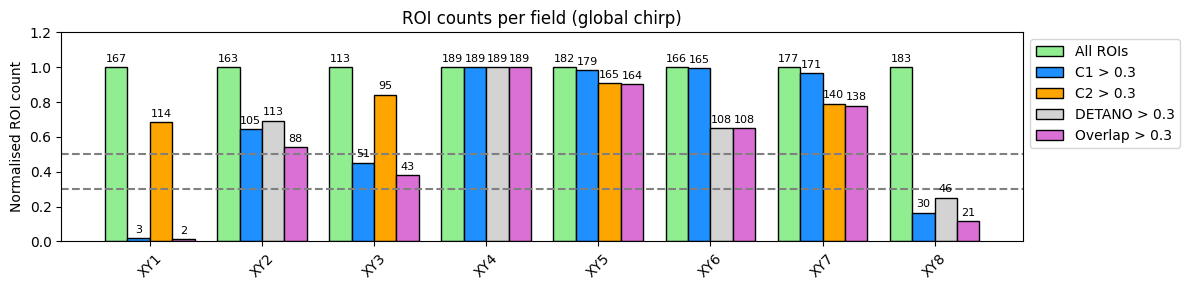

In [80]:
# Convert your results list into a pandas DataFrame for easier grouping
df = pd.DataFrame(results_rois)

# To store summary results
summary = []

# Group by field
for field, group in df.groupby("field"):
    # Expect two conditions per field (e.g., C1 + C2 or C1 + DETA/NO)
    conditions = group["condition"].values
    if len(conditions) < 2:
        print(f"Skipping {field} (only one condition found)")
        continue

    cond1, cond2 = conditions[:2]

    # Extract maximum number of ROIs
    max_num_rois = group[group["condition"] == cond1]["num_of_rois"].iloc[0]
    
    # Extract ROIs for each condition
    rois_c1 = set(group[group["condition"] == cond1]["rois"].iloc[0])
    rois_c2 = set(group[group["condition"] == cond2]["rois"].iloc[0])

    # Compute overlaps
    overlap = rois_c1.intersection(rois_c2)
    
    entry = {
        "field": field,
        "cond1": cond1,
        "cond2": cond2,
        "num_all_rois": max_num_rois,
        "num_rois_c1": len(rois_c1),
        "num_rois_c2": len(rois_c2),
        "num_overlap": len(overlap)
    }
    summary.append(entry)

# Convert summary to DataFrame
df_summary = pd.DataFrame(summary)
print(df_summary)

# Normalize counts within each field by the max (All ROIs)
df_summary["norm_all"] = df_summary["num_all_rois"] / df_summary["num_all_rois"]
df_summary["norm_c1"] = df_summary["num_rois_c1"] / df_summary["num_all_rois"]
df_summary["norm_c2"] = df_summary["num_rois_c2"] / df_summary["num_all_rois"]
df_summary["norm_overlap"] = df_summary["num_overlap"] / df_summary["num_all_rois"]

# Bar positions and widths
x = np.arange(len(df_summary))
width = 0.2

# Fixed colors
color_all = "lightgreen"
color_c1 = "dodgerblue"
color_overlap = "orchid"

# Determine color for cond2 per field
cond2_colors = ["orange" if cond == "C2" else "lightgray" for cond in df_summary["cond2"]]

# Create figure
fig, ax = plt.subplots(figsize=(12, 3))

# Plot bars
bars_all = ax.bar(x - 1.5*width, df_summary["norm_all"], width, color=color_all, edgecolor='black')
bars_c1 = ax.bar(x - 0.5*width, df_summary["norm_c1"], width, color=color_c1, edgecolor='black')
bars_c2 = ax.bar(x + 0.5*width, df_summary["norm_c2"], width, color=cond2_colors, edgecolor='black')
bars_overlap = ax.bar(x + 1.5*width, df_summary["norm_overlap"], width, color=color_overlap, edgecolor='black')

# Add numeric labels on top of bars
def add_labels(bars, values):
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{int(val)}",
                ha='center', va='bottom', fontsize=8) #, fontweight='bold')

add_labels(bars_all, df_summary["num_all_rois"])
add_labels(bars_c1, df_summary["num_rois_c1"])
add_labels(bars_c2, df_summary["num_rois_c2"])
add_labels(bars_overlap, df_summary["num_overlap"])

# Set x-axis
ax.set_xticks(x)
ax.set_xticklabels(df_summary["field"], rotation=45)
ax.set_ylabel("Normalised ROI count")
ax.set_title("ROI counts per field (global chirp)")
ax.set_ylim(0, 1.2)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color_all, edgecolor='black', label="All ROIs"),
    Patch(facecolor=color_c1, edgecolor='black', label="C1 > 0.3"),
    Patch(facecolor="orange", edgecolor='black', label="C2 > 0.3"),
    Patch(facecolor="lightgray", edgecolor='black', label="DETANO > 0.3"),
    Patch(facecolor=color_overlap, edgecolor='black', label="Overlap > 0.3")
]

ax.legend(handles=legend_elements, bbox_to_anchor=(1, 1))
ax.axhline(y=0.30, color="gray", linestyle="--", linewidth=1.5)
#ax.axhline(y=0.40, color="gray", linestyle="--", linewidth=1.5)
ax.axhline(y=0.50, color="gray", linestyle="--", linewidth=1.5)
ax.set_ylim(0, 1.2)  # add headroom for labels

plt.tight_layout()
plt.savefig("plots/20251023/quality/gchirp_roi_number_filtering_per_field.png",
            dpi=300,
            bbox_inches="tight")

## Local Chirp

In [81]:
# Define date, and stimulus
stimulus = "lChirp"

In [82]:
# Retrieve all fields of that day
fields = (ChirpQI() & {"date": date, "stim_name": stimulus}).fetch("field")
fields = np.unique(fields)
fields

[2025-11-05 14:44:49,081][WARNING]: Reconnecting to MySQL server.


array(['XY1', 'XY2', 'XY3', 'XY4', 'XY5', 'XY6', 'XY7', 'XY8'],
      dtype=object)

In [83]:
# Retrieve all conditions on that date
conditions = (ChirpQI() & {"date": date, "stim_name": stimulus}).fetch("cond2")
conditions = np.unique(conditions)
conditions

array(['C1', 'C2', 'DETANO'], dtype=object)

In [84]:
# Retrieve # of ROIs in all fields with global chirp QI > 0.3
for field in fields:
    rois_filtered = ((ChirpQI() & {"date": date, "field": field, "cond2": "C1", "stim_name": stimulus}) & "qidx > 0.3").fetch("roi_id")
    print(f"Number of ROIs in {field} with C1 QI > 0.3: {len(rois_filtered)}")

Number of ROIs in XY1 with C1 QI > 0.3: 16
Number of ROIs in XY2 with C1 QI > 0.3: 0
Number of ROIs in XY3 with C1 QI > 0.3: 91
Number of ROIs in XY4 with C1 QI > 0.3: 188
Number of ROIs in XY5 with C1 QI > 0.3: 163
Number of ROIs in XY6 with C1 QI > 0.3: 48
Number of ROIs in XY7 with C1 QI > 0.3: 52
Number of ROIs in XY8 with C1 QI > 0.3: 7


In [85]:
# Collect info in a dictionary
results_rois = []

# Adapt code to all conditions
for field in fields:
    available_conditions = (ChirpQI() & {"date": date, "field": field, "stim_name": stimulus}).fetch("cond2")
    available_conditions = np.unique(available_conditions)
    
    for condition in available_conditions:

        rois = ((ChirpQI() & {"date": date, "field": field, "cond2": condition, "stim_name": stimulus})).fetch("roi_id")
        rois_filtered = ((ChirpQI() & {"date": date, "field": field, "cond2": condition, "stim_name": stimulus}) & "qidx > 0.3").fetch("roi_id")

        entry = {
            "date": date,
            "field": field,
            "condition": condition,
            "stimulus": stimulus,
            "num_of_rois": len(rois),
            "num_rois_filtered": len(rois_filtered),
            "rois": rois_filtered}

        results_rois.append(entry)

        print(f"Number of ROIs (unfiltered): {len(rois)}")
        print(f"Number of ROIs in {field} with {condition} QI > 0.3: {len(rois_filtered)}")

#print(results_rois)

Number of ROIs (unfiltered): 167
Number of ROIs in XY1 with C1 QI > 0.3: 16
Number of ROIs (unfiltered): 167
Number of ROIs in XY1 with C2 QI > 0.3: 29
Number of ROIs (unfiltered): 163
Number of ROIs in XY2 with C1 QI > 0.3: 0
Number of ROIs (unfiltered): 163
Number of ROIs in XY2 with DETANO QI > 0.3: 12
Number of ROIs (unfiltered): 113
Number of ROIs in XY3 with C1 QI > 0.3: 91
Number of ROIs (unfiltered): 113
Number of ROIs in XY3 with C2 QI > 0.3: 110
Number of ROIs (unfiltered): 189
Number of ROIs in XY4 with C1 QI > 0.3: 188
Number of ROIs (unfiltered): 189
Number of ROIs in XY4 with DETANO QI > 0.3: 184
Number of ROIs (unfiltered): 182
Number of ROIs in XY5 with C1 QI > 0.3: 163
Number of ROIs (unfiltered): 182
Number of ROIs in XY5 with C2 QI > 0.3: 16
Number of ROIs (unfiltered): 166
Number of ROIs in XY6 with C1 QI > 0.3: 48
Number of ROIs (unfiltered): 166
Number of ROIs in XY6 with DETANO QI > 0.3: 20
Number of ROIs (unfiltered): 177
Number of ROIs in XY7 with C1 QI > 0.3: 

  field cond1   cond2  num_all_rois  num_rois_c1  num_rois_c2  num_overlap
0   XY1    C1      C2           167           16           29            9
1   XY2    C1  DETANO           163            0           12            0
2   XY3    C1      C2           113           91          110           91
3   XY4    C1  DETANO           189          188          184          184
4   XY5    C1      C2           182          163           16           15
5   XY6    C1  DETANO           166           48           20           18
6   XY7    C1      C2           177           52            2            2
7   XY8    C1  DETANO           183            7            9            0


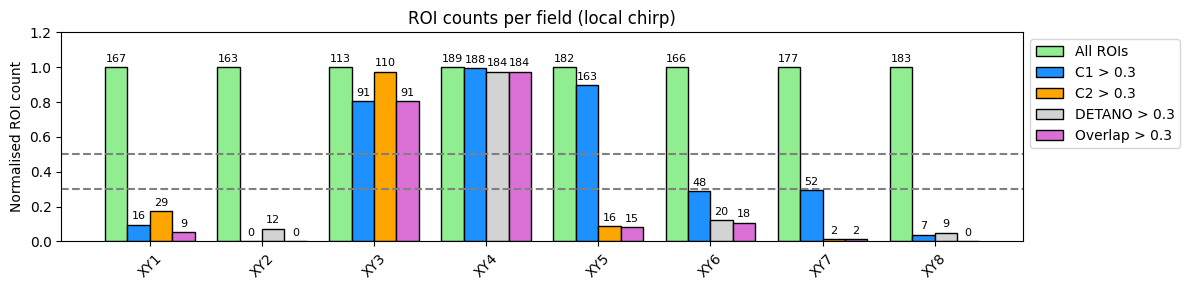

In [86]:
# Convert your results list into a pandas DataFrame for easier grouping
df = pd.DataFrame(results_rois)

# To store summary results
summary = []

# Group by field
for field, group in df.groupby("field"):
    # Expect two conditions per field (e.g., C1 + C2 or C1 + DETA/NO)
    conditions = group["condition"].values
    if len(conditions) < 2:
        print(f"Skipping {field} (only one condition found)")
        continue

    cond1, cond2 = conditions[:2]

    # Extract maximum number of ROIs
    max_num_rois = group[group["condition"] == cond1]["num_of_rois"].iloc[0]
    
    # Extract ROIs for each condition
    rois_c1 = set(group[group["condition"] == cond1]["rois"].iloc[0])
    rois_c2 = set(group[group["condition"] == cond2]["rois"].iloc[0])

    # Compute overlaps
    overlap = rois_c1.intersection(rois_c2)
    
    entry = {
        "field": field,
        "cond1": cond1,
        "cond2": cond2,
        "num_all_rois": max_num_rois,
        "num_rois_c1": len(rois_c1),
        "num_rois_c2": len(rois_c2),
        "num_overlap": len(overlap)
    }
    summary.append(entry)

# Convert summary to DataFrame
df_summary = pd.DataFrame(summary)
print(df_summary)

# Normalize counts within each field by the max (All ROIs)
df_summary["norm_all"] = df_summary["num_all_rois"] / df_summary["num_all_rois"]
df_summary["norm_c1"] = df_summary["num_rois_c1"] / df_summary["num_all_rois"]
df_summary["norm_c2"] = df_summary["num_rois_c2"] / df_summary["num_all_rois"]
df_summary["norm_overlap"] = df_summary["num_overlap"] / df_summary["num_all_rois"]

# Bar positions and widths
x = np.arange(len(df_summary))
width = 0.2

# Fixed colors
color_all = "lightgreen"
color_c1 = "dodgerblue"
color_overlap = "orchid"

# Determine color for cond2 per field
cond2_colors = ["orange" if cond == "C2" else "lightgray" for cond in df_summary["cond2"]]

# Create figure
fig, ax = plt.subplots(figsize=(12, 3))

# Plot bars
bars_all = ax.bar(x - 1.5*width, df_summary["norm_all"], width, color=color_all, edgecolor='black')
bars_c1 = ax.bar(x - 0.5*width, df_summary["norm_c1"], width, color=color_c1, edgecolor='black')
bars_c2 = ax.bar(x + 0.5*width, df_summary["norm_c2"], width, color=cond2_colors, edgecolor='black')
bars_overlap = ax.bar(x + 1.5*width, df_summary["norm_overlap"], width, color=color_overlap, edgecolor='black')

# Add numeric labels on top of bars
def add_labels(bars, values):
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{int(val)}",
                ha='center', va='bottom', fontsize=8) #, fontweight='bold')

add_labels(bars_all, df_summary["num_all_rois"])
add_labels(bars_c1, df_summary["num_rois_c1"])
add_labels(bars_c2, df_summary["num_rois_c2"])
add_labels(bars_overlap, df_summary["num_overlap"])

# Set x-axis
ax.set_xticks(x)
ax.set_xticklabels(df_summary["field"], rotation=45)
ax.set_ylabel("Normalised ROI count")
ax.set_title("ROI counts per field (local chirp)")
ax.set_ylim(0, 1.2)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color_all, edgecolor='black', label="All ROIs"),
    Patch(facecolor=color_c1, edgecolor='black', label="C1 > 0.3"),
    Patch(facecolor="orange", edgecolor='black', label="C2 > 0.3"),
    Patch(facecolor="lightgray", edgecolor='black', label="DETANO > 0.3"),
    Patch(facecolor=color_overlap, edgecolor='black', label="Overlap > 0.3")
]

ax.legend(handles=legend_elements, bbox_to_anchor=(1, 1))
ax.axhline(y=0.30, color="gray", linestyle="--", linewidth=1.5)
#ax.axhline(y=0.40, color="gray", linestyle="--", linewidth=1.5)
ax.axhline(y=0.50, color="gray", linestyle="--", linewidth=1.5)
ax.set_ylim(0, 1.2)  # add headroom for labels

plt.tight_layout()
plt.savefig("plots/20251023/quality/lchirp_roi_number_filtering_per_field.png",
            dpi=300,
            bbox_inches="tight")

## Moving Bars

In [87]:
# Define date, and stimulus
stimulus = "movingbar"

In [88]:
# Retrieve all fields of that day
fields = (OsDsIndexes() & {"date": date, "stim_name": stimulus}).fetch("field")
fields = np.unique(fields)
fields

array(['XY1', 'XY2', 'XY3', 'XY4', 'XY5', 'XY6', 'XY7', 'XY8'],
      dtype=object)

In [89]:
# Retrieve all conditions on that date
conditions = (OsDsIndexes() & {"date": date, "stim_name": stimulus}).fetch("cond2")
conditions = np.unique(conditions)
conditions

array(['C1', 'C2', 'DETANO'], dtype=object)

In [90]:
# Retrieve # of ROIs in all fields with moving bar QI > 0.6
for field in fields:
    rois_filtered = ((OsDsIndexes() & {"date": date, "field": field, "cond2": "C1", "stim_name": stimulus}) & "d_qi > 0.6").fetch("roi_id")
    print(f"Number of ROIs in {field} with C1 QI > 0.3: {len(rois_filtered)}")

Number of ROIs in XY1 with C1 QI > 0.3: 51
Number of ROIs in XY2 with C1 QI > 0.3: 12
Number of ROIs in XY3 with C1 QI > 0.3: 25
Number of ROIs in XY4 with C1 QI > 0.3: 185
Number of ROIs in XY5 with C1 QI > 0.3: 181
Number of ROIs in XY6 with C1 QI > 0.3: 68
Number of ROIs in XY7 with C1 QI > 0.3: 153
Number of ROIs in XY8 with C1 QI > 0.3: 14


In [91]:
# Collect info in a dictionary
results_rois = []

# Adapt code to all conditions
for field in fields:
    available_conditions = (OsDsIndexes() & {"date": date, "field": field, "stim_name": stimulus}).fetch("cond2")
    available_conditions = np.unique(available_conditions)
    
    for condition in available_conditions:

        rois = ((OsDsIndexes() & {"date": date, "field": field, "cond2": condition, "stim_name": stimulus})).fetch("roi_id")
        rois_filtered = ((OsDsIndexes() & {"date": date, "field": field, "cond2": condition, "stim_name": stimulus}) & "d_qi > 0.6").fetch("roi_id")

        entry = {
            "date": date,
            "field": field,
            "condition": condition,
            "stimulus": stimulus,
            "num_of_rois": len(rois),
            "num_rois_filtered": len(rois_filtered),
            "rois": rois_filtered}

        results_rois.append(entry)

        print(f"Number of ROIs (unfiltered): {len(rois)}")
        print(f"Number of ROIs in {field} with {condition} QI > 0.3: {len(rois_filtered)}")

#print(results_rois)

Number of ROIs (unfiltered): 167
Number of ROIs in XY1 with C1 QI > 0.3: 51
Number of ROIs (unfiltered): 167
Number of ROIs in XY1 with C2 QI > 0.3: 25
Number of ROIs (unfiltered): 163
Number of ROIs in XY2 with C1 QI > 0.3: 12
Number of ROIs (unfiltered): 163
Number of ROIs in XY2 with DETANO QI > 0.3: 17
Number of ROIs (unfiltered): 113
Number of ROIs in XY3 with C1 QI > 0.3: 25
Number of ROIs (unfiltered): 113
Number of ROIs in XY3 with C2 QI > 0.3: 67
Number of ROIs (unfiltered): 189
Number of ROIs in XY4 with C1 QI > 0.3: 185
Number of ROIs (unfiltered): 189
Number of ROIs in XY4 with DETANO QI > 0.3: 189
Number of ROIs (unfiltered): 182
Number of ROIs in XY5 with C1 QI > 0.3: 181
Number of ROIs (unfiltered): 182
Number of ROIs in XY5 with C2 QI > 0.3: 72
Number of ROIs (unfiltered): 166
Number of ROIs in XY6 with C1 QI > 0.3: 68
Number of ROIs (unfiltered): 166
Number of ROIs in XY6 with DETANO QI > 0.3: 88
Number of ROIs (unfiltered): 177
Number of ROIs in XY7 with C1 QI > 0.3: 

  field cond1   cond2  num_all_rois  num_rois_c1  num_rois_c2  num_overlap
0   XY1    C1      C2           167           51           25            8
1   XY2    C1  DETANO           163           12           17            6
2   XY3    C1      C2           113           25           67           13
3   XY4    C1  DETANO           189          185          189          185
4   XY5    C1      C2           182          181           72           71
5   XY6    C1  DETANO           166           68           88           42
6   XY7    C1      C2           177          153           67           65
7   XY8    C1  DETANO           183           14            6            0


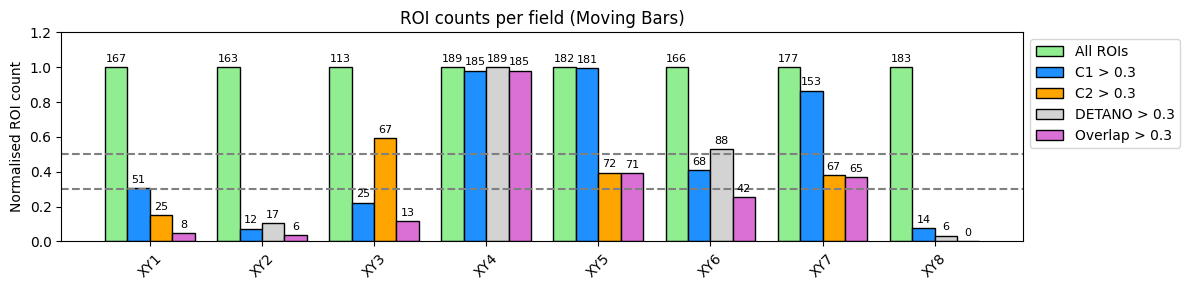

In [93]:
# Convert your results list into a pandas DataFrame for easier grouping
df = pd.DataFrame(results_rois)

# To store summary results
summary = []

# Group by field
for field, group in df.groupby("field"):
    # Expect two conditions per field (e.g., C1 + C2 or C1 + DETA/NO)
    conditions = group["condition"].values
    if len(conditions) < 2:
        print(f"Skipping {field} (only one condition found)")
        continue

    cond1, cond2 = conditions[:2]

    # Extract maximum number of ROIs
    max_num_rois = group[group["condition"] == cond1]["num_of_rois"].iloc[0]
    
    # Extract ROIs for each condition
    rois_c1 = set(group[group["condition"] == cond1]["rois"].iloc[0])
    rois_c2 = set(group[group["condition"] == cond2]["rois"].iloc[0])

    # Compute overlaps
    overlap = rois_c1.intersection(rois_c2)
    
    entry = {
        "field": field,
        "cond1": cond1,
        "cond2": cond2,
        "num_all_rois": max_num_rois,
        "num_rois_c1": len(rois_c1),
        "num_rois_c2": len(rois_c2),
        "num_overlap": len(overlap)
    }
    summary.append(entry)

# Convert summary to DataFrame
df_summary = pd.DataFrame(summary)
print(df_summary)

# Normalize counts within each field by the max (All ROIs)
df_summary["norm_all"] = df_summary["num_all_rois"] / df_summary["num_all_rois"]
df_summary["norm_c1"] = df_summary["num_rois_c1"] / df_summary["num_all_rois"]
df_summary["norm_c2"] = df_summary["num_rois_c2"] / df_summary["num_all_rois"]
df_summary["norm_overlap"] = df_summary["num_overlap"] / df_summary["num_all_rois"]

# Bar positions and widths
x = np.arange(len(df_summary))
width = 0.2

# Fixed colors
color_all = "lightgreen"
color_c1 = "dodgerblue"
color_overlap = "orchid"

# Determine color for cond2 per field
cond2_colors = ["orange" if cond == "C2" else "lightgray" for cond in df_summary["cond2"]]

# Create figure
fig, ax = plt.subplots(figsize=(12, 3))

# Plot bars
bars_all = ax.bar(x - 1.5*width, df_summary["norm_all"], width, color=color_all, edgecolor='black')
bars_c1 = ax.bar(x - 0.5*width, df_summary["norm_c1"], width, color=color_c1, edgecolor='black')
bars_c2 = ax.bar(x + 0.5*width, df_summary["norm_c2"], width, color=cond2_colors, edgecolor='black')
bars_overlap = ax.bar(x + 1.5*width, df_summary["norm_overlap"], width, color=color_overlap, edgecolor='black')

# Add numeric labels on top of bars
def add_labels(bars, values):
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{int(val)}",
                ha='center', va='bottom', fontsize=8) #, fontweight='bold')

add_labels(bars_all, df_summary["num_all_rois"])
add_labels(bars_c1, df_summary["num_rois_c1"])
add_labels(bars_c2, df_summary["num_rois_c2"])
add_labels(bars_overlap, df_summary["num_overlap"])

# Set x-axis
ax.set_xticks(x)
ax.set_xticklabels(df_summary["field"], rotation=45)
ax.set_ylabel("Normalised ROI count")
ax.set_title("ROI counts per field (Moving Bars)")
ax.set_ylim(0, 1.2)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color_all, edgecolor='black', label="All ROIs"),
    Patch(facecolor=color_c1, edgecolor='black', label="C1 > 0.3"),
    Patch(facecolor="orange", edgecolor='black', label="C2 > 0.3"),
    Patch(facecolor="lightgray", edgecolor='black', label="DETANO > 0.3"),
    Patch(facecolor=color_overlap, edgecolor='black', label="Overlap > 0.3")
]

ax.legend(handles=legend_elements, bbox_to_anchor=(1, 1))
ax.axhline(y=0.30, color="gray", linestyle="--", linewidth=1.5)
#ax.axhline(y=0.40, color="gray", linestyle="--", linewidth=1.5)
ax.axhline(y=0.50, color="gray", linestyle="--", linewidth=1.5)
ax.set_ylim(0, 1.2)  # add headroom for labels

plt.tight_layout()
plt.savefig("plots/20251023/quality/MB_roi_number_filtering_per_field.png",
            dpi=300,
            bbox_inches="tight")